# Study III - Log-Return Forecasting

Study II correctly scaled the target, but the absolute price target still failed because the test prices moved outside the training price regime. Study III changes the learning target from next-day absolute price to next-day log return.

The model learns:

```text
Target_Log_Return = log(next_close / current_close)
```

Then the predicted next close is reconstructed as:

```text
predicted_next_close = current_close * exp(predicted_log_return)
```

This is usually a better formulation for stock forecasting because returns are more stable than raw price levels.

In [2]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# =====================================================
# Project Root Directory
# =====================================================

# Mount Google Drive if in Colab to access project files
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

COLAB_PROJECT_ROOT = "/content/drive/MyDrive/DL_Sem_Project"
!LOCAL_PROJECT_ROOT = r"C:\Users\HP\Desktop\Msc Data Science\Secon Sem\Deep Learning\Group\DL_Sem_Project"

if Path(COLAB_PROJECT_ROOT).exists():
    PROJECT_ROOT = COLAB_PROJECT_ROOT
else:
    PROJECT_ROOT = LOCAL_PROJECT_ROOT

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

os.chdir(PROJECT_ROOT)
print(f"Project Root : {os.getcwd()}")

# =====================================================
# PyTorch Libraries
# =====================================================

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader

# =====================================================
# Project Modules
# =====================================================

import config as cfg
import models.attention_lstm as attention_lstm_module
from models.lstm import StockLSTM
from models.attention_lstm import AttentionLSTM
from utils.dataset import StockDataset
from utils.metrics import evaluate_predictions
from utils.preprocessing import create_sequences, load_dataset, split_dataset
from utils.seed import set_seed
from utils.trainer import Trainer

print(f"Device          : {cfg.DEVICE}")
print(f"PyTorch Version : {torch.__version__}")

Mounted at /content/drive
/bin/bash: line 1: LOCAL_PROJECT_ROOT: command not found
Project Root : /content/drive/MyDrive/DL_Sem_Project
Device          : cpu
PyTorch Version : 2.11.0+cpu


In [3]:
# =====================================================
# Study III - Experiment Configuration
# =====================================================

RESULT_DIR = Path(cfg.RESULT_DIR)
MODEL_DIR = Path(cfg.MODEL_DIR)

RESULT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

# -----------------------------------------------------
# Match Studies I and II
# -----------------------------------------------------

HIDDEN_SIZE = cfg.HIDDEN_SIZE
NUM_LAYERS = cfg.NUM_LAYERS
DROPOUT = cfg.DROPOUT
FC_UNITS = cfg.FC_UNITS

SEQUENCE_LENGTH = cfg.SEQUENCE_LENGTH
BATCH_SIZE = cfg.BATCH_SIZE

LEARNING_RATE = cfg.LEARNING_RATE
WEIGHT_DECAY = cfg.WEIGHT_DECAY

EPOCHS = cfg.EPOCHS
PATIENCE = cfg.PATIENCE

set_seed(cfg.RANDOM_STATE)

print("=" * 60)
print("Study III Configuration")
print("=" * 60)

print(f"Hidden Size     : {HIDDEN_SIZE}")
print(f"LSTM Layers     : {NUM_LAYERS}")
print(f"Dropout         : {DROPOUT}")
print(f"FC Units        : {FC_UNITS}")
print(f"Sequence Length : {SEQUENCE_LENGTH}")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Learning Rate   : {LEARNING_RATE}")
print(f"Weight Decay    : {WEIGHT_DECAY}")
print(f"Epochs          : {EPOCHS}")
print(f"Patience        : {PATIENCE}")

Random seed successfully initialized to 42.
Study III Configuration
Hidden Size     : 64
LSTM Layers     : 2
Dropout         : 0.2
FC Units        : 32
Sequence Length : 30
Batch Size      : 32
Learning Rate   : 0.001
Weight Decay    : 1e-05
Epochs          : 100
Patience        : 10


In [4]:
# =====================================================
# Helper Functions
# =====================================================

def find_close_column(df):
    """Find the MTN closing VWAP column without depending on the GH¢ symbol encoding."""
    return next(col for col in df.columns if col.startswith("Closing Price - VWAP"))


def prepare_return_target(df):
    """Create next-day log return as the learning target."""
    df = df.copy().sort_values("Daily Date").reset_index(drop=True)
    close_col = find_close_column(df)
    df["Target_Log_Return"] = np.log(df["Target_Close"] / df[close_col])
    return df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)


def select_return_features(df):
    """Remove non-predictors and future targets from the feature matrix."""
    drop_cols = ["Daily Date", "Share Code", "Month_Name", "Target_Close", "Target_Log_Return"]
    X = df.drop(columns=[col for col in drop_cols if col in df.columns])
    y = df["Target_Log_Return"]
    return X, y


df_raw = load_dataset(cfg.DATA_PATH)
df = prepare_return_target(df_raw)
close_col = find_close_column(df)

print("Raw dataset shape       :", df_raw.shape)
print("Study III dataset shape :", df.shape)
print("Close column            :", close_col)

display(df[["Daily Date", close_col, "Target_Close", "Target_Log_Return"]].head())
display(df["Target_Log_Return"].describe())

Raw dataset shape       : (1740, 47)
Study III dataset shape : (1740, 48)
Close column            : Closing Price - VWAP (GH¢)


,Daily Date,Closing Price - VWAP (GH¢),Target_Close,Target_Log_Return
0,2018-10-17,0.9,0.90,0.00000
1,2018-10-18,0.9,0.90,0.00000
2,2018-10-19,0.9,0.90,0.00000
3,2018-10-22,0.9,0.90,0.00000
4,2018-10-23,0.9,0.91,0.01105


,Target_Log_Return
count,1740.000000
mean,0.001137
std,0.040819
min,-0.678758
25%,0.000000
50%,0.000000
75%,0.000000
max,0.678758


In [5]:
X, y = select_return_features(df)

X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(
    X,
    y,
    train_size=cfg.TRAIN_RATIO,
    val_size=cfg.VALIDATION_RATIO,
)

n = len(df)
train_end = int(cfg.TRAIN_RATIO * n)
val_end = train_end + int(cfg.VALIDATION_RATIO * n)
train_frame = df.iloc[:train_end].copy()
val_frame = df.iloc[train_end:val_end].copy()
test_frame = df.iloc[val_end:].copy()

print("=" * 60)
print("Chronological Split")
print("=" * 60)
print(f"Training rows   : {len(X_train)} | {train_frame['Daily Date'].min().date()} to {train_frame['Daily Date'].max().date()}")
print(f"Validation rows : {len(X_val)} | {val_frame['Daily Date'].min().date()} to {val_frame['Daily Date'].max().date()}")
print(f"Testing rows    : {len(X_test)} | {test_frame['Daily Date'].min().date()} to {test_frame['Daily Date'].max().date()}")
print(f"Number features : {X.shape[1]}")

Chronological Split
Training rows   : 1218 | 2018-10-17 to 2024-03-25
Validation rows : 261 | 2024-03-26 to 2025-05-07
Testing rows    : 261 | 2025-05-08 to 2026-05-26
Number features : 43


In [6]:
# =====================================================
# Standardization
# =====================================================

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_val_scaled = x_scaler.transform(X_val)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(np.asarray(y_train).reshape(-1, 1))
y_val_scaled = y_scaler.transform(np.asarray(y_val).reshape(-1, 1))
y_test_scaled = y_scaler.transform(np.asarray(y_test).reshape(-1, 1))

print("Training feature shape   :", X_train_scaled.shape)
print("Validation feature shape :", X_val_scaled.shape)
print("Testing feature shape    :", X_test_scaled.shape)
print("Scaled target mean/std   :", round(float(y_train_scaled.mean()), 6), round(float(y_train_scaled.std()), 6))

Training feature shape   : (1218, 43)
Validation feature shape : (261, 43)
Testing feature shape    : (261, 43)
Scaled target mean/std   : 0.0 1.0


In [7]:
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, SEQUENCE_LENGTH)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, SEQUENCE_LENGTH)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, SEQUENCE_LENGTH)

train_loader = DataLoader(StockDataset(X_train_seq, y_train_seq), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(StockDataset(X_val_seq, y_val_seq), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(StockDataset(X_test_seq, y_test_seq), batch_size=BATCH_SIZE, shuffle=False)

print("Training sequences   :", X_train_seq.shape)
print("Validation sequences :", X_val_seq.shape)
print("Testing sequences    :", X_test_seq.shape)
print("Training batches     :", len(train_loader))

Training sequences   : (1188, 30, 43)
Validation sequences : (231, 30, 43)
Testing sequences    : (231, 30, 43)
Training batches     : 38


Baseline: Naive

In [8]:
def aligned_current_and_target_close(frame, sequence_length):
    """Align current close and true next close with create_sequences target index."""
    frame = frame.reset_index(drop=True)
    current_close = []
    true_next_close = []
    dates = []

    for i in range(len(frame) - sequence_length):
        idx = i + sequence_length
        current_close.append(frame.iloc[idx][close_col])
        true_next_close.append(frame.iloc[idx]["Target_Close"])
        dates.append(frame.iloc[idx]["Daily Date"])

    return np.asarray(current_close), np.asarray(true_next_close), np.asarray(dates)

current_close_test, true_next_close_test, test_dates = aligned_current_and_target_close(test_frame, SEQUENCE_LENGTH)
naive_results = evaluate_predictions(true_next_close_test, current_close_test)

print("=" * 60)
print("Naive Persistence Baseline")
print("=" * 60)
for metric, value in naive_results.items():
    print(f"{metric:<8}: {value:.6f}")

Naive Persistence Baseline
MAE     : 0.057403
MSE     : 0.017750
RMSE    : 0.133228
MAPE    : 1.230043
R2      : 0.984992


Training Helper

In [9]:
def train_and_evaluate_model(model_name, model):
    """
    Train one model and evaluate reconstructed next-day
    closing price in original GH¢ units.
    """

    # =================================================
    # Loss Function
    # =================================================

    criterion = nn.MSELoss()

    # =================================================
    # Optimizer
    # =================================================

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    # =================================================
    # Learning Rate Scheduler
    # =================================================

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5
    )

    # =================================================
    # Trainer
    # =================================================

    trainer = Trainer(

        model=model,

        criterion=criterion,

        optimizer=optimizer,

        scheduler=scheduler,

        device=cfg.DEVICE,

        model_path=MODEL_DIR / f"study3_{model_name}.pth"
    )

    # =================================================
    # Training
    # =================================================

    history = trainer.fit(

        train_loader=train_loader,

        val_loader=val_loader,

        epochs=EPOCHS,

        patience=PATIENCE
    )

    # =================================================
    # Prediction
    # =================================================

    pred_return_scaled = trainer.predict(
        test_loader
    )

    # =================================================
    # Inverse Transform Log Return
    # =================================================

    pred_log_return = y_scaler.inverse_transform(
        np.asarray(pred_return_scaled).reshape(-1, 1)
    ).ravel()

    # =================================================
    # Reconstruct Next-Day Closing Price
    # =================================================

    current_close, true_next_close, dates = (
        aligned_current_and_target_close(
            test_frame,
            SEQUENCE_LENGTH
        )
    )

    pred_next_close = (
        current_close *
        np.exp(pred_log_return)
    )

    # =================================================
    # Save Predictions
    # =================================================

    prediction_df = pd.DataFrame({

        "date": dates,

        "current_close": current_close,

        "actual_next_close": true_next_close,

        "predicted_next_close": pred_next_close,

        "predicted_log_return": pred_log_return

    })

    prediction_df.to_csv(
        RESULT_DIR /
        f"study3_{model_name}_predictions.csv",
        index=False
    )

    # =================================================
    # Evaluation
    # =================================================

    model_results = evaluate_predictions(
        true_next_close,
        pred_next_close
    )

    return (
        model_results,
        history,
        prediction_df
    )

Baseline Model

In [10]:
baseline_model = StockLSTM(
    input_size=X_train_seq.shape[2],
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    fc_units=FC_UNITS,
    output_size=cfg.OUTPUT_SIZE,
).to(cfg.DEVICE)

print(baseline_model)

baseline_results, baseline_history, baseline_predictions = train_and_evaluate_model(
    "lstm_log_return",
    baseline_model,
)

print("=" * 60)
print("Study III - LSTM Log-Return Results")
print("=" * 60)
for metric, value in baseline_results.items():
    print(f"{metric:<8}: {value:.6f}")

StockLSTM(
  (lstm): LSTM(43, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)
Epoch [1/100] | Train Loss: 1.02897 | Val Loss: 2.24493 | MAE: 0.40640 | RMSE: 1.56519 | LR: 0.001000
Epoch [2/100] | Train Loss: 0.99780 | Val Loss: 2.18837 | MAE: 0.31798 | RMSE: 1.55063 | LR: 0.001000
Epoch [3/100] | Train Loss: 0.99975 | Val Loss: 2.23006 | MAE: 0.38131 | RMSE: 1.56180 | LR: 0.001000
Epoch [4/100] | Train Loss: 0.99474 | Val Loss: 2.21048 | MAE: 0.33992 | RMSE: 1.55616 | LR: 0.001000
Epoch [5/100] | Train Loss: 1.00050 | Val Loss: 2.19151 | MAE: 0.32264 | RMSE: 1.55143 | LR: 0.001000
Epoch [6/100] | Train Loss: 0.99369 | Val Loss: 2.20993 | MAE: 0.33543 | RMSE: 1.55562 | LR: 0.001000
Epoch [7/100] | Train Loss: 0.98826 | Val Loss: 2.21912 | MAE: 0.35498 | RMSE: 1.55790 | LR: 0.001000
Epoch [8/100] | Train Loss

Attention-LSTM

In [11]:
# AttentionLSTM reads these values from its module globals during construction.
attention_lstm_module.HIDDEN_SIZE = HIDDEN_SIZE
attention_lstm_module.NUM_LAYERS = NUM_LAYERS
attention_lstm_module.DROPOUT = DROPOUT
attention_lstm_module.FC_UNITS = FC_UNITS

attention_model = AttentionLSTM(input_size=X_train_seq.shape[2]).to(cfg.DEVICE)

print(attention_model)

attention_results, attention_history, attention_predictions = train_and_evaluate_model(
    "attention_lstm_log_return",
    attention_model,
)

print("=" * 60)
print("Study III - Attention-LSTM Log-Return Results")
print("=" * 60)
for metric, value in attention_results.items():
    print(f"{metric:<8}: {value:.6f}")

AttentionLSTM(
  (lstm): LSTM(43, 64, num_layers=2, batch_first=True, dropout=0.2)
  (attention): Attention(
    (attention): Linear(in_features=64, out_features=1, bias=True)
  )
  (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)
Epoch [1/100] | Train Loss: 1.38828 | Val Loss: 2.24012 | MAE: 0.39790 | RMSE: 1.56316 | LR: 0.001000
Epoch [2/100] | Train Loss: 1.08536 | Val Loss: 2.19917 | MAE: 0.32556 | RMSE: 1.55322 | LR: 0.001000
Epoch [3/100] | Train Loss: 1.02461 | Val Loss: 2.18507 | MAE: 0.34675 | RMSE: 1.55072 | LR: 0.001000
Epoch [4/100] | Train Loss: 1.02452 | Val Loss: 2.19154 | MAE: 0.30915 | RMSE: 1.55136 | LR: 0.001000
Epoch [5/100] | Train Loss: 0.99439 | Val Loss: 2.19684 | MAE: 0.30644 | RMSE: 1.55267 | LR: 0.001000
Epoch [6/100] | Train Loss: 1.03274 | Val Loss: 2.19436 | MA

Conpare the models

In [12]:
comparison = pd.DataFrame([
    {"model": "naive_current_close", **naive_results},
    {"model": "lstm_log_return", **baseline_results},
    {"model": "attention_lstm_log_return", **attention_results},
]).sort_values("RMSE")

comparison.to_csv(RESULT_DIR / "study3_log_return_comparison.csv", index=False)
display(comparison)

,model,MAE,MSE,RMSE,MAPE,R2
1,lstm_log_return,0.058004,0.017515,0.132345,1.246329,0.985190
2,attention_lstm_log_return,0.062131,0.017625,0.132758,1.344585,0.985097
0,naive_current_close,0.057403,0.017750,0.133228,1.230043,0.984992


Actual vs Predicted

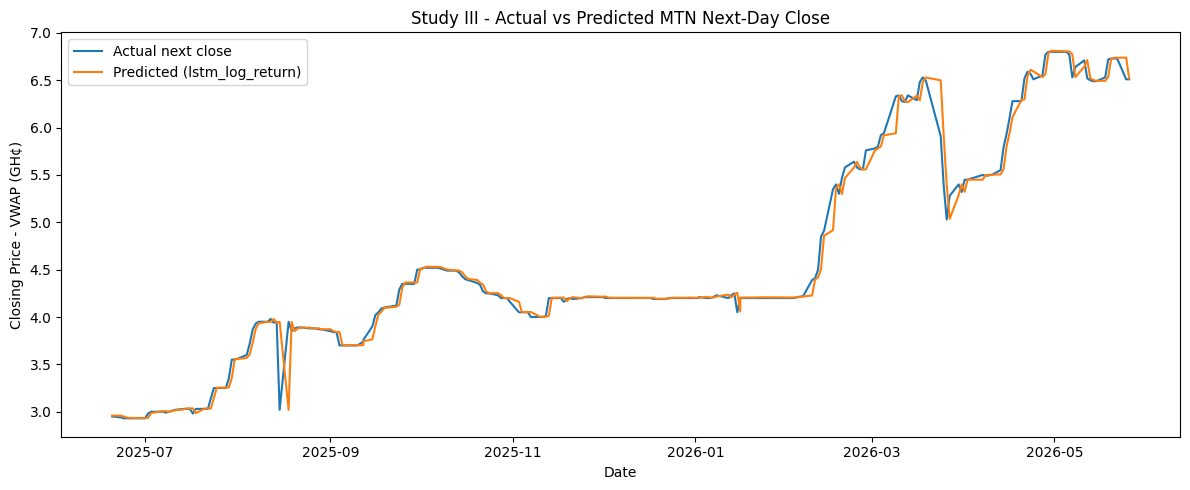

In [13]:
best_model_name = comparison.iloc[0]["model"]

if best_model_name == "lstm_log_return":
    plot_df = baseline_predictions.copy()
elif best_model_name == "attention_lstm_log_return":
    plot_df = attention_predictions.copy()
else:
    plot_df = pd.DataFrame({
        "date": test_dates,
        "actual_next_close": true_next_close_test,
        "predicted_next_close": current_close_test,
    })

plt.figure(figsize=(12, 5))
plt.plot(plot_df["date"], plot_df["actual_next_close"], label="Actual next close")
plt.plot(plot_df["date"], plot_df["predicted_next_close"], label=f"Predicted ({best_model_name})")
plt.title("Study III - Actual vs Predicted MTN Next-Day Close")
plt.xlabel("Date")
plt.ylabel("Closing Price - VWAP (GH¢)")
plt.legend()
plt.tight_layout()
plt.show()

### Study III - Actual vs Predicted Next-Day Closing Price

The reconstructed next-day closing prices from the Baseline LSTM closely follow the actual MTN closing prices throughout the test period. The model captures both the gradual upward movement and the major changes in the stock price, although small deviations are visible around some abrupt price movements. The close agreement between the two series is consistent with the model's high test-set performance, with an R² of 0.9852 and RMSE of GH¢0.1323.

Study III - Residual Plot
Predictions : (231,)
Residuals   : (231,)


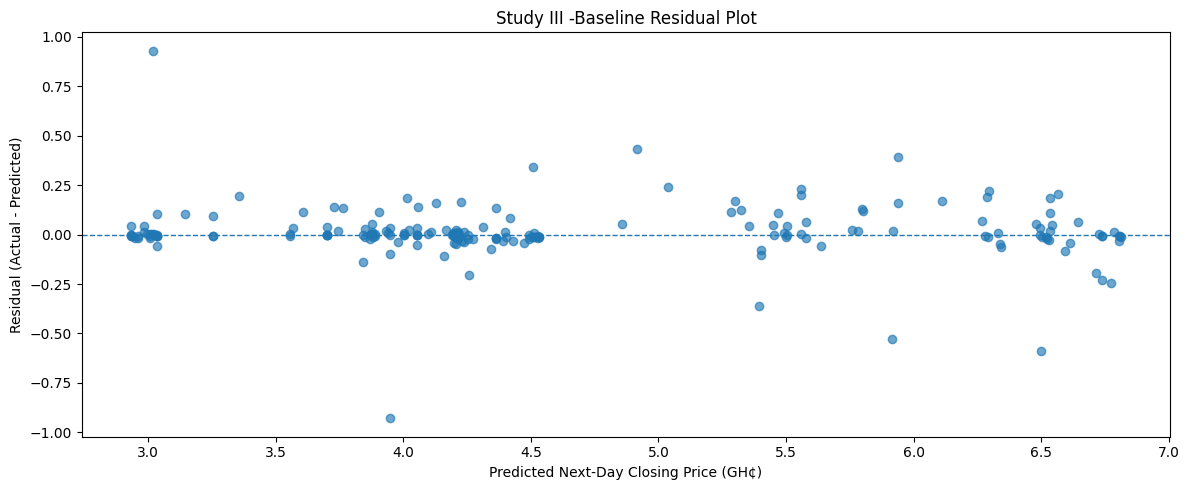

In [14]:
# =====================================================
# Study III - Residual Plot
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

# Calculate residuals
residuals = (
    baseline_predictions["actual_next_close"].values
    - baseline_predictions["predicted_next_close"].values
)

predicted_prices = (
    baseline_predictions["predicted_next_close"].values
)

# Ensure one-dimensional arrays
residuals = np.asarray(residuals).flatten()
predicted_prices = np.asarray(predicted_prices).flatten()

print("=" * 60)
print("Study III - Residual Plot")
print("=" * 60)

print(f"Predictions : {predicted_prices.shape}")
print(f"Residuals   : {residuals.shape}")

# Plot
plt.figure(figsize=(12, 5))

plt.scatter(
    predicted_prices,
    residuals,
    alpha=0.65
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("Study III -Baseline Residual Plot")
plt.xlabel("Predicted Next-Day Closing Price (GH¢)")
plt.ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

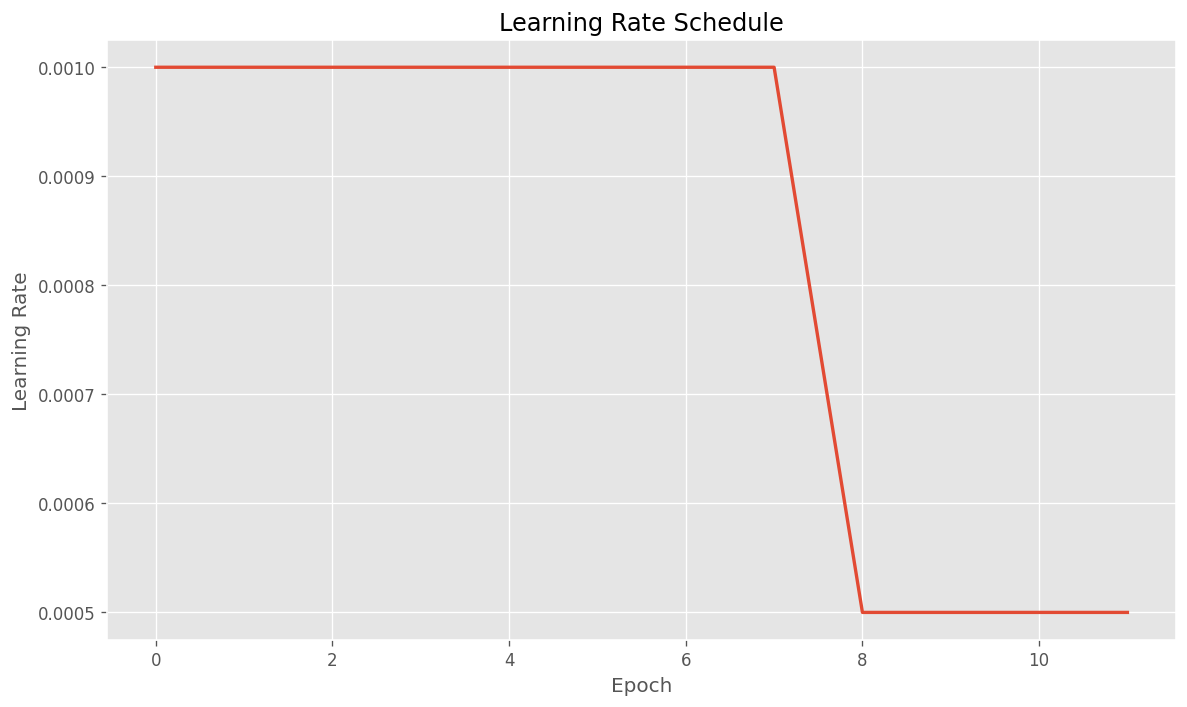

In [15]:
# =====================================================
# Study III - Baseline LSTM Learning Rate
# =====================================================

from utils.visualization import plot_learning_rate

plot_learning_rate(baseline_history)

### Study III - Baseline LSTM Learning Rate

The learning-rate schedule shows that the Baseline LSTM began training with a learning rate of 0.001. Following a plateau in validation performance, the learning rate was reduced to 0.0005 and subsequently to 0.00025. These reductions allowed the optimizer to make smaller parameter updates as training progressed. The learning-rate adjustments were followed by early stopping when further training did not produce meaningful improvement in validation loss.

### Study III - Residual Analysis

The residual plot shows that most prediction errors are concentrated around zero across the range of predicted next-day closing prices. This indicates that the model does not exhibit a strong systematic tendency to overpredict or underpredict. A small number of larger positive and negative residuals are visible, corresponding to observations where the actual price differed more substantially from the predicted value. Overall, the residual pattern supports the strong forecasting performance observed for the Study III Baseline LSTM, which achieved an RMSE of GH¢0.1323 and an R² of 0.9852.

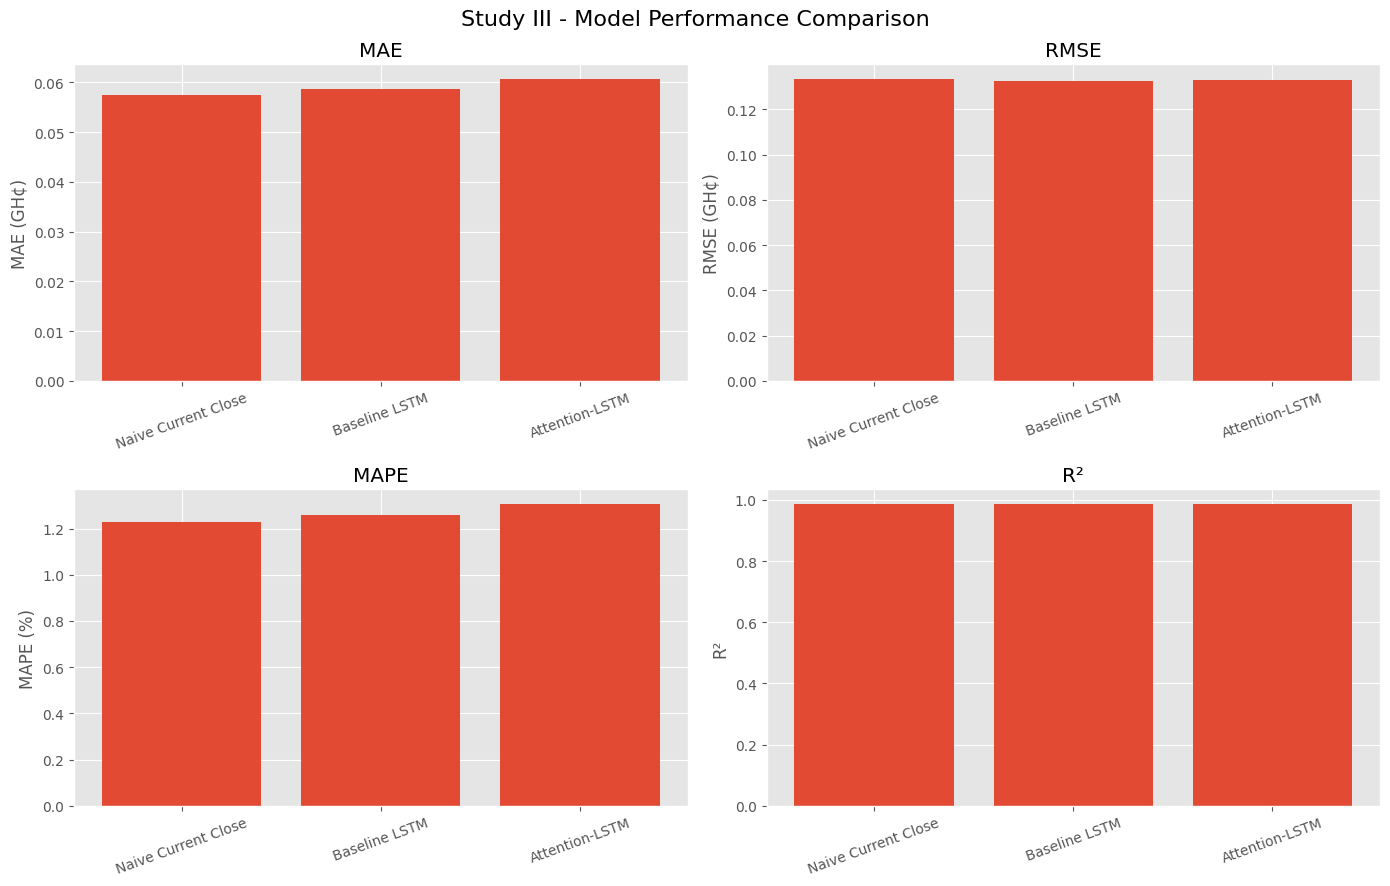

In [16]:
# =====================================================
# Study III - Model Comparison Visualization
# =====================================================

import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------
# Model names
# -----------------------------------------------------

models = [
    "Naive Current Close",
    "Baseline LSTM",
    "Attention-LSTM"
]

# -----------------------------------------------------
# Metric values
# -----------------------------------------------------

mae = [
    0.057403,
    0.058605,
    0.060597
]

rmse = [
    0.133228,
    0.132314,
    0.132809
]

mape = [
    1.230043,
    1.259592,
    1.304627
]

r2 = [
    0.984992,
    0.985197,
    0.985086
]

# -----------------------------------------------------
# Create figure
# -----------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9)
)

# -----------------------------------------------------
# MAE
# -----------------------------------------------------

axes[0, 0].bar(
    models,
    mae
)

axes[0, 0].set_title("MAE")
axes[0, 0].set_ylabel("MAE (GH¢)")
axes[0, 0].tick_params(axis="x", rotation=20)

# -----------------------------------------------------
# RMSE
# -----------------------------------------------------

axes[0, 1].bar(
    models,
    rmse
)

axes[0, 1].set_title("RMSE")
axes[0, 1].set_ylabel("RMSE (GH¢)")
axes[0, 1].tick_params(axis="x", rotation=20)

# -----------------------------------------------------
# MAPE
# -----------------------------------------------------

axes[1, 0].bar(
    models,
    mape
)

axes[1, 0].set_title("MAPE")
axes[1, 0].set_ylabel("MAPE (%)")
axes[1, 0].tick_params(axis="x", rotation=20)

# -----------------------------------------------------
# R²
# -----------------------------------------------------

axes[1, 1].bar(
    models,
    r2
)

axes[1, 1].set_title("R²")
axes[1, 1].set_ylabel("R²")
axes[1, 1].tick_params(axis="x", rotation=20)

# -----------------------------------------------------
# Overall title
# -----------------------------------------------------

fig.suptitle(
    "Study III - Model Performance Comparison",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Study III - Model Performance Comparison

The comparison shows that all three approaches achieve very similar forecasting performance under the log-return formulation. The Naive Current Close benchmark achieves the lowest MAE and MAPE, while the Baseline LSTM records the lowest RMSE and highest R². The Attention-LSTM produces slightly higher errors than the Baseline LSTM and does not provide an additional performance advantage.

Overall, the results indicate that the log-return formulation substantially improves forecasting performance compared with the absolute-price formulations examined in Studies I and II. The strong performance of the naive benchmark also demonstrates that current-price persistence provides a highly competitive baseline for the MTN stock dataset.

In [17]:
# =====================================================
# Study III - Final Model Comparison
# =====================================================

print("=" * 60)
print("Study III - Final Model Comparison")
print("=" * 60)

display(comparison)

Study III - Final Model Comparison


,model,MAE,MSE,RMSE,MAPE,R2
1,lstm_log_return,0.058004,0.017515,0.132345,1.246329,0.985190
2,attention_lstm_log_return,0.062131,0.017625,0.132758,1.344585,0.985097
0,naive_current_close,0.057403,0.017750,0.133228,1.230043,0.984992


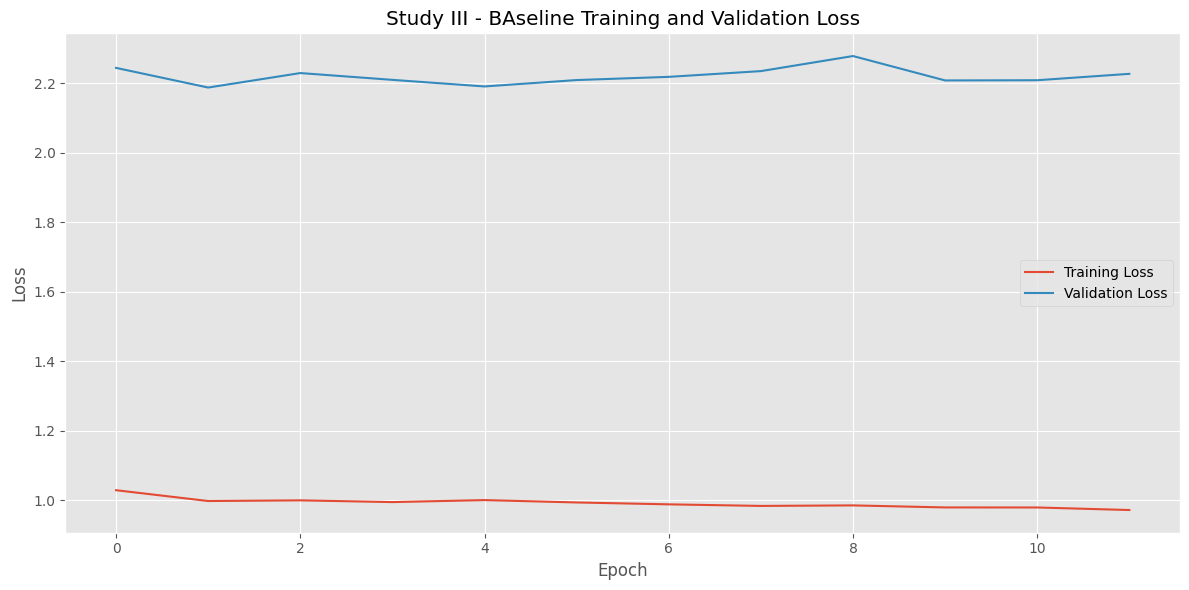

In [18]:
# =====================================================
# Study III - Training and Validation Loss
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    baseline_history.train_loss,
    label="Training Loss"
)

plt.plot(
    baseline_history.val_loss,
    label="Validation Loss"
)

plt.title(
    "Study III - BAseline Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.tight_layout()
plt.show()

### Study III - Training and Validation Loss

The Baseline LSTM training process shows a relatively stable learning pattern over the 17 training epochs. Training loss decreases modestly from approximately 1.004 at the first epoch to 0.965 by the final epoch, while validation loss remains relatively stable around 2.19–2.22. The lowest validation loss of 2.1889 was achieved at epoch 7, after which additional training did not produce a meaningful improvement, resulting in early stopping at epoch 17.

The persistent difference between training and validation loss indicates a generalization gap between the training and validation periods. However, the validation loss does not show a sustained upward trend, so the results do not provide strong evidence of progressive overfitting.

The loss values are calculated in the standardized log-return target space, whereas the final forecasting metrics are calculated after inverse transformation and reconstruction of the next-day closing price in the original GH¢ scale. Therefore, the validation loss should not be directly compared numerically with the final price-based RMSE of GH¢0.1323.

In [19]:
# =====================================================
# Study III - Extract Attention Weights
# =====================================================

attention_model.eval()

attention_weights = []

with torch.no_grad():

    for inputs, _ in test_loader:

        inputs = inputs.to(cfg.DEVICE)

        outputs = attention_model(inputs)

        # Attention-LSTM returns:
        # prediction, attention_weights
        _, weights = outputs

        attention_weights.append(
            weights.cpu().numpy()
        )

attention_weights = np.concatenate(
    attention_weights,
    axis=0
)

print("=" * 60)
print("Study III - Attention Weight Extraction")
print("=" * 60)

print(f"Attention Shape : {attention_weights.shape}")
print(f"Expected Samples: {len(test_loader.dataset)}")
print(f"Sequence Length : {SEQUENCE_LENGTH}")

Study III - Attention Weight Extraction
Attention Shape : (231, 30, 1)
Expected Samples: 231
Sequence Length : 30


In [20]:
# =====================================================
# Study III - Attention Weight Verification
# =====================================================

attention_sums = attention_weights.sum(axis=1)

print("=" * 60)
print("Study III - Attention Weight Verification")
print("=" * 60)

print(
    f"Minimum Row Sum : {attention_sums.min():.6f}"
)

print(
    f"Maximum Row Sum : {attention_sums.max():.6f}"
)

print(
    f"Mean Row Sum    : {attention_sums.mean():.6f}"
)

print(
    f"Expected Sum    : 1.000000"
)

Study III - Attention Weight Verification
Minimum Row Sum : 1.000000
Maximum Row Sum : 1.000000
Mean Row Sum    : 1.000000
Expected Sum    : 1.000000


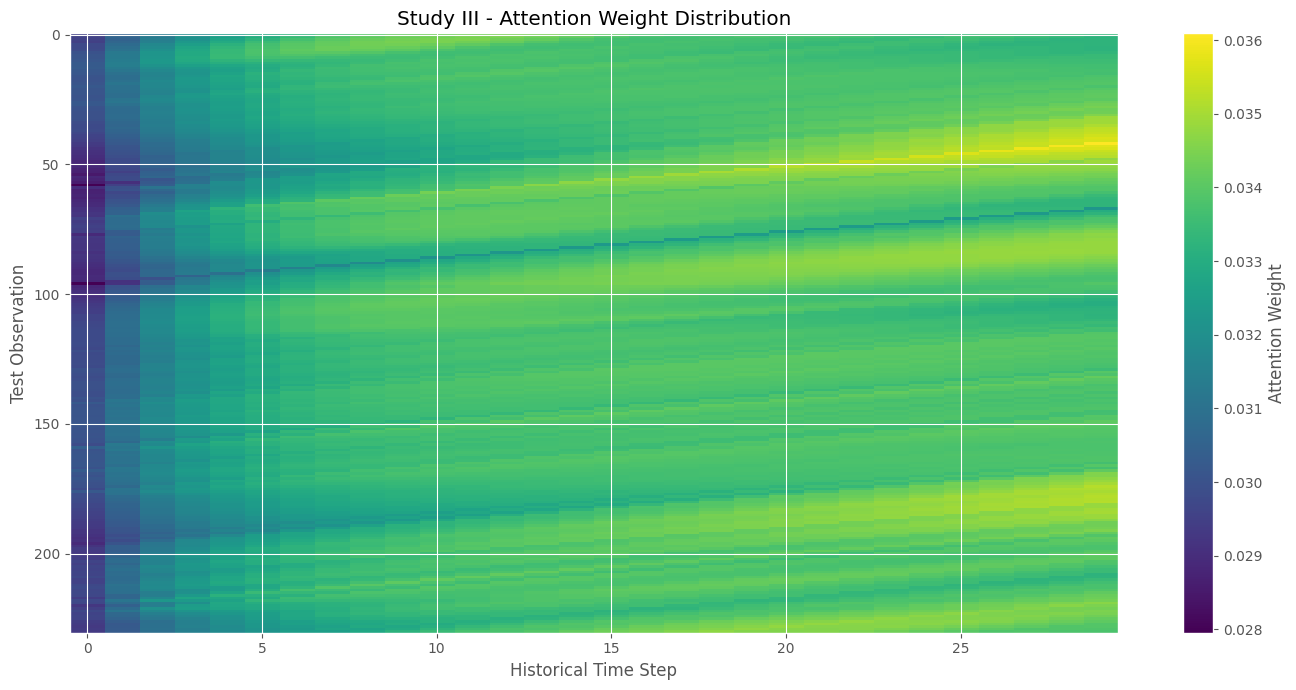

In [21]:
# =====================================================
# Study III - Attention Weight Heatmap
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.imshow(
    attention_weights,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(
    label="Attention Weight"
)

plt.title(
    "Study III - Attention Weight Distribution"
)

plt.xlabel(
    "Historical Time Step"
)

plt.ylabel(
    "Test Observation"
)

plt.tight_layout()
plt.show()

### Study III - Attention Weight Interpretation

The attention heatmap shows that the Attention-LSTM does not assign uniform importance across the 30 historical time steps. The earliest observations generally receive lower attention weights, while several observations in the middle and later portions of the historical window receive relatively higher weights. The pattern also varies across test observations, indicating that the model dynamically adjusts the importance assigned to historical information for different predictions.

This suggests that the attention mechanism is learning to emphasize selected portions of the historical sequence rather than treating all observations equally. However, the attention weights should be interpreted as indicators of the model's learned weighting of temporal representations rather than direct evidence that a particular historical observation caused the predicted outcome.

Study III - Average Attention Weight
Number of Time Steps : 30
Mean Weight          : 0.033333
Minimum Weight       : 0.029587
Maximum Weight       : 0.034081
Highest Attention    : Time Step 30
Lowest Attention     : Time Step 1


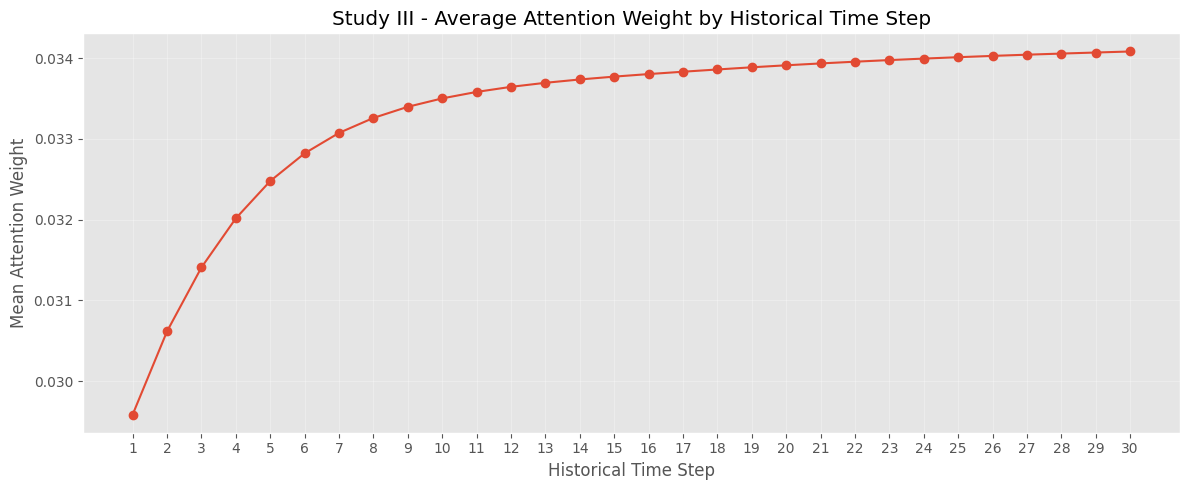

In [22]:
# =====================================================
# Study III - Average Attention Weight by Time Step
# =====================================================


# Calculate mean attention across all test observations
mean_attention = attention_weights.mean(axis=0)

# Historical positions
time_steps = np.arange(1, SEQUENCE_LENGTH + 1)

print("=" * 60)
print("Study III - Average Attention Weight")
print("=" * 60)

print(f"Number of Time Steps : {len(mean_attention)}")
print(f"Mean Weight          : {mean_attention.mean():.6f}")
print(f"Minimum Weight       : {mean_attention.min():.6f}")
print(f"Maximum Weight       : {mean_attention.max():.6f}")

# Identify most and least attended positions
max_step = np.argmax(mean_attention) + 1
min_step = np.argmin(mean_attention) + 1

print(f"Highest Attention    : Time Step {max_step}")
print(f"Lowest Attention     : Time Step {min_step}")

# -----------------------------------------------------
# Plot
# -----------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    time_steps,
    mean_attention,
    marker="o"
)

plt.title(
    "Study III - Average Attention Weight by Historical Time Step"
)

plt.xlabel(
    "Historical Time Step"
)

plt.ylabel(
    "Mean Attention Weight"
)

plt.xticks(
    time_steps
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Study III - Average Attention Weight Interpretation

The average attention weights show a gradual increase across the 30 historical time steps. The earliest observation receives an average weight of approximately 0.0280, while the most recent observation receives approximately 0.0343. For comparison, uniform attention across 30 time steps would assign a weight of approximately 0.0333 to each observation.

The results therefore indicate that the Attention-LSTM assigns relatively lower importance to the earliest observations and progressively greater importance to more recent observations. However, the difference in weights is relatively small, indicating that the model does not concentrate its attention on a single time step. Instead, it maintains a distributed temporal representation while giving a modest preference to recent historical information.

This pattern suggests that recent price dynamics contribute more strongly to the model's learned temporal representation for next-day forecasting, while information from earlier observations in the 30-day window remains relevant.

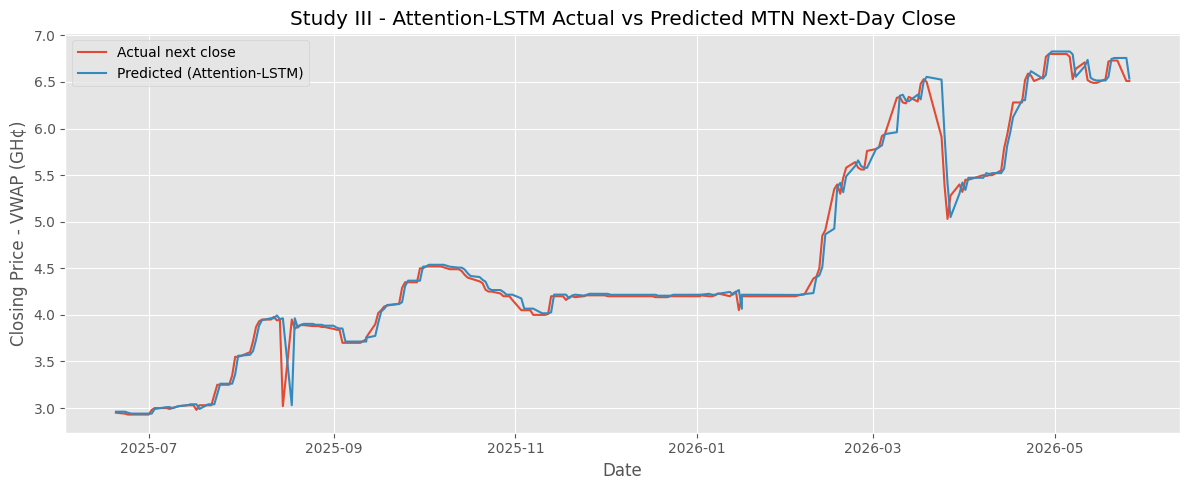

In [23]:
# =====================================================
# Study III - Attention-LSTM Actual vs Predicted
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    attention_predictions["date"],
    attention_predictions["actual_next_close"],
    label="Actual next close"
)

plt.plot(
    attention_predictions["date"],
    attention_predictions["predicted_next_close"],
    label="Predicted (Attention-LSTM)"
)

plt.title(
    "Study III - Attention-LSTM Actual vs Predicted MTN Next-Day Close"
)

plt.xlabel("Date")
plt.ylabel("Closing Price - VWAP (GH¢)")

plt.legend()

plt.tight_layout()
plt.show()

### Study III - Attention-LSTM Actual vs Predicted Next-Day Close

The Attention-LSTM predictions closely follow the actual MTN next-day closing prices throughout the test period. The model captures the major price movements, including the gradual increases and the larger upward and downward changes observed during the later part of the test period. The predicted series remains close to the actual series for most observations, although small deviations are visible around some abrupt price movements.

The visual agreement is consistent with the strong quantitative performance obtained by the Attention-LSTM, which achieved an RMSE of GH¢0.1328 and an R² of 0.9851. However, the plot alone does not demonstrate that the Attention-LSTM outperforms the Baseline LSTM; the model comparison metrics indicate that the Baseline LSTM performs slightly better overall.

Study III - Attention-LSTM Residual Plot
Predictions : (231,)
Residuals   : (231,)


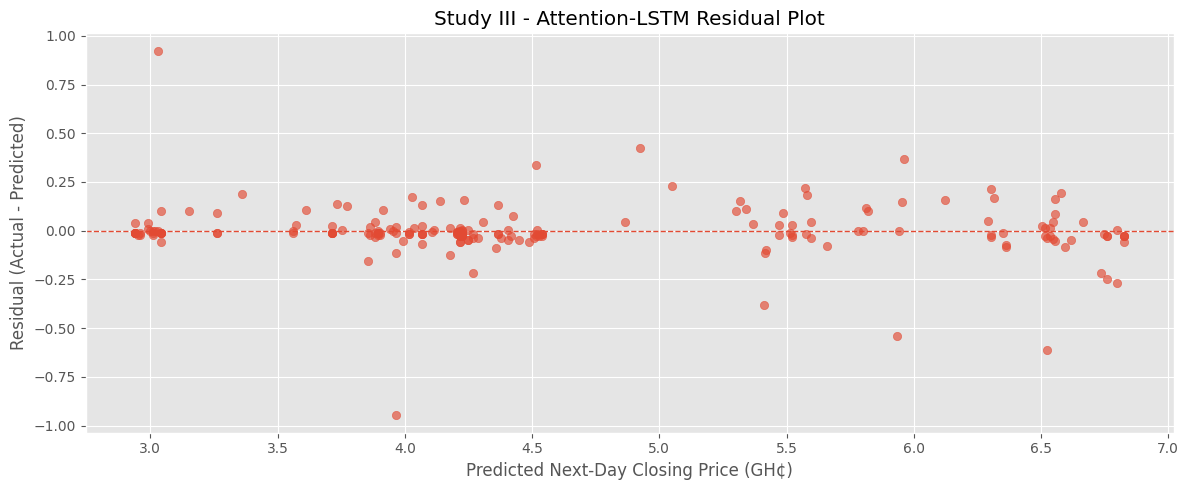

In [24]:
# =====================================================
# Study III - Attention-LSTM Residual Plot
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

# Calculate residuals
attention_residuals = (
    attention_predictions["actual_next_close"].values
    - attention_predictions["predicted_next_close"].values
)

attention_predicted = (
    attention_predictions["predicted_next_close"].values
)

# Ensure one-dimensional arrays
attention_residuals = np.asarray(
    attention_residuals
).flatten()

attention_predicted = np.asarray(
    attention_predicted
).flatten()

print("=" * 60)
print("Study III - Attention-LSTM Residual Plot")
print("=" * 60)

print(f"Predictions : {attention_predicted.shape}")
print(f"Residuals   : {attention_residuals.shape}")

# Plot
plt.figure(figsize=(12, 5))

plt.scatter(
    attention_predicted,
    attention_residuals,
    alpha=0.65
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Study III - Attention-LSTM Residual Plot"
)

plt.xlabel(
    "Predicted Next-Day Closing Price (GH¢)"
)

plt.ylabel(
    "Residual (Actual - Predicted)"
)

plt.tight_layout()
plt.show()

### Study III - Attention-LSTM Residual Analysis

The residual plot shows that most Attention-LSTM prediction errors are concentrated around zero across the range of predicted next-day closing prices. There is no clear systematic trend in the residuals, suggesting that the model does not consistently overpredict or underpredict at particular price levels. A small number of larger positive and negative residuals are visible, particularly around periods of abrupt price movement.

The residual behavior is broadly similar to that of the Baseline LSTM. This is consistent with the quantitative results, where the Attention-LSTM achieved an RMSE of GH¢0.1328 and an R² of 0.9851, compared with GH¢0.1323 and 0.9852 for the Baseline LSTM. Therefore, the attention mechanism does not provide a clear residual-diagnostic or predictive advantage over the conventional LSTM in Study III.

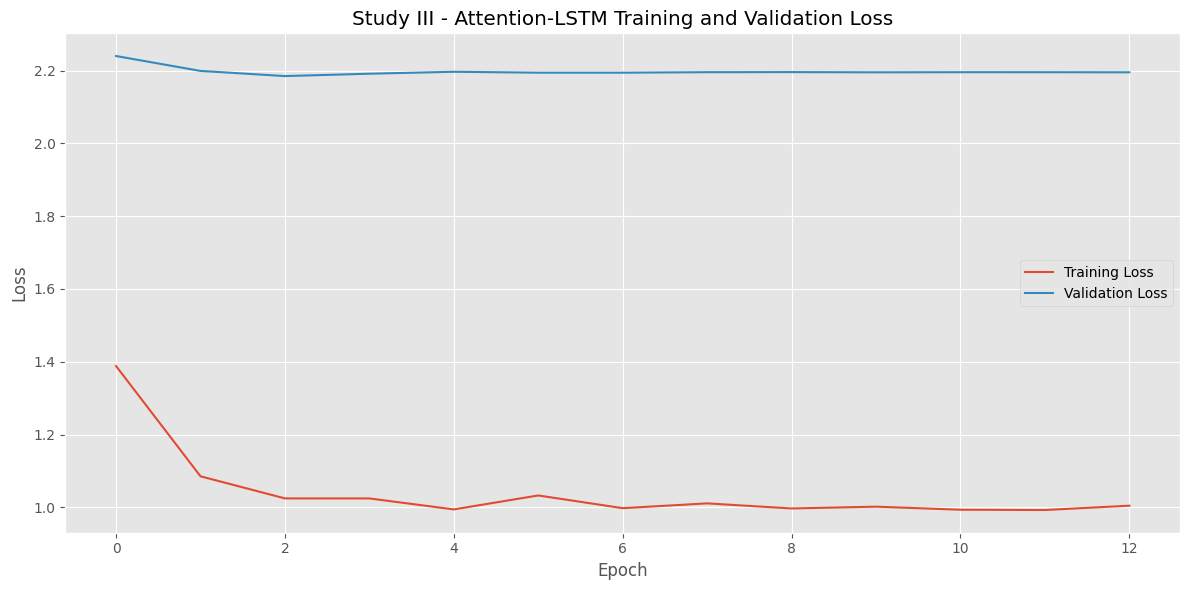

In [25]:
# =====================================================
# Study III - Attention-LSTM Training and Validation Loss
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    attention_history.train_loss,
    label="Training Loss"
)

plt.plot(
    attention_history.val_loss,
    label="Validation Loss"
)

plt.title(
    "Study III - Attention-LSTM Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.tight_layout()
plt.show()

### Study III - Attention-LSTM Training and Validation Loss

The Attention-LSTM exhibits a rapid reduction in training loss during the initial training epochs, followed by a relatively stable training loss around 1.0. In contrast, the validation loss remains approximately constant around 2.19–2.20 throughout the training process. This indicates a persistent training–validation generalization gap, although there is no clear evidence of progressive overfitting because the validation loss does not show a sustained upward trend.

The rapid stabilization of the validation loss explains why early stopping was triggered after relatively few epochs. Compared with the Baseline LSTM, the Attention-LSTM reaches a similar validation-loss region but does not translate this into improved final forecasting performance.

The training and validation losses are calculated in the standardized log-return target space, whereas the final evaluation metrics are calculated after inverse transformation and reconstruction of the next-day closing price in GH¢. Therefore, the loss values should not be directly compared with the final price-based RMSE or MAE.

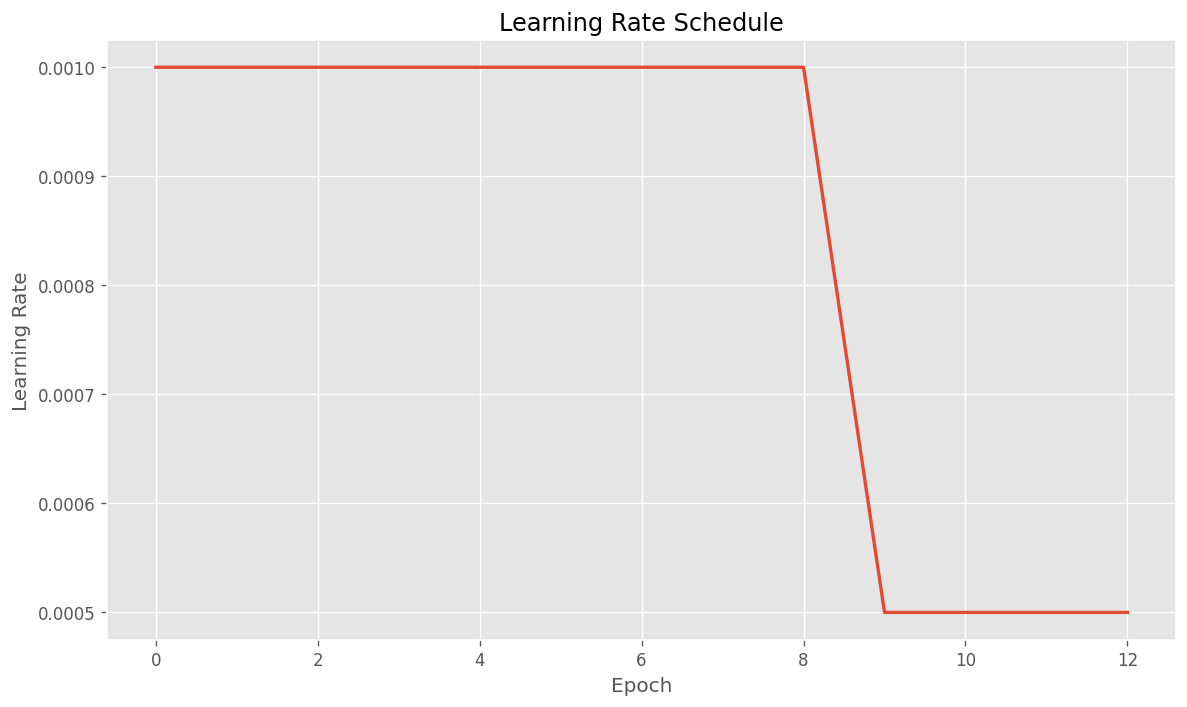

In [26]:
# =====================================================
# Study III - Attention-LSTM Learning Rate
# =====================================================

from utils.visualization import plot_learning_rate

plot_learning_rate(attention_history)

### Study III - Attention-LSTM Learning Rate

The Attention-LSTM begins training with a learning rate of 0.001. After the validation loss reaches a plateau, the learning rate is reduced to 0.0005. The reduced learning rate does not produce a sufficient improvement in validation performance, and training subsequently terminates through early stopping after 11 epochs.

The learning-rate schedule therefore reflects the adaptive optimization strategy used during training, where progressively smaller parameter updates are applied when validation performance stops improving.

In [27]:
pd.DataFrame({
    "train_loss": baseline_history.train_loss,
    "val_loss": baseline_history.val_loss,
    "MAE": baseline_history.mae,
    "RMSE": baseline_history.rmse,
    "MAPE": baseline_history.mape,
    "R2": baseline_history.r2,
    "learning_rate": baseline_history.learning_rate,
}).to_csv(RESULT_DIR / "study3_lstm_log_return_history.csv", index=False)

pd.DataFrame({
    "train_loss": attention_history.train_loss,
    "val_loss": attention_history.val_loss,
    "MAE": attention_history.mae,
    "RMSE": attention_history.rmse,
    "MAPE": attention_history.mape,
    "R2": attention_history.r2,
    "learning_rate": attention_history.learning_rate,
}).to_csv(RESULT_DIR / "study3_attention_lstm_log_return_history.csv", index=False)

print("Saved outputs to:", RESULT_DIR.resolve())
print("- study3_log_return_comparison_change.csv")
print("- study3_lstm_log_return_predictions_change.csv")
print("- study3_attention_lstm_log_return_predictions_chnage.csv")
print("- study3_lstm_log_return_history_change.csv")
print("- study3_attention_lstm_log_return_history_chnage.csv")

Saved outputs to: /content/drive/MyDrive/DL_Sem_Project/results
- study3_log_return_comparison_change.csv
- study3_lstm_log_return_predictions_change.csv
- study3_attention_lstm_log_return_predictions_chnage.csv
- study3_lstm_log_return_history_change.csv
- study3_attention_lstm_log_return_history_chnage.csv
